In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax.training import checkpoints
from tqdm.notebook import trange

from pinn.train_curv import (
    create_train_state, make_train_step,
    initial_loss, loss_dict_to_batched, assemble_loss_history, 
    plot_loss_history_ax, 
)
from pinn.utils import (
    load_pts_data, strip_meta,
    save_ckpt, pick, sample_surface_points, save_pts_data
)

import tifffile as tiff
from pinn.plot import (
    visualize_cryoET_with_contours,
    visualize_phase,
    plot_normalized_loss_history_ax,
)

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
    _layout.DeviceLocalLayout = _layout.Layout
    print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))

NUM_CHECKPOINTS_TO_KEEP = 1000

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


In [2]:
def plot_result(
    checkpoint_dir, 
    data_id,
    shape,
    steps_to_visualize=(0, 1000, 5000, 10000), 
    save_interval=100,
    axis = "x",
):

    # Decide which checkpoints to load (based on your save interval)
    max_step = max(steps_to_visualize)
    steps_series = list(range(0, max_step + 1, save_interval))

    # ---- Load checkpoints ----
    checkpoint_data = {}
    for step in steps_series:
        ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        if os.path.exists(ckpt_path):
            checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)

    # Ensure the requested steps exist (otherwise plotting will crash / skip)
    steps_to_visualize = [s for s in steps_to_visualize if s in checkpoint_data]
    if len(steps_to_visualize) == 0:
        print(f"[plot_result] No checkpoints found in {checkpoint_dir}")
        return

    # ---- Load cryoET volume ----
    tif_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
    cryoET_data = tiff.imread(tif_file_path)
    cryoET_data = 1 - cryoET_data
    grid_size = cryoET_data.shape[0]
    slice_index = grid_size // 2

    # ---- Make figure ----
    fig = plt.figure(figsize=(3 * 4, 12))

    # Row 1: CryoET + contours
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, i + 1)
        visualize_cryoET_with_contours(
            ax, step, checkpoint_data[step], cryoET_data,
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            thresholding=False
        )
        if i == 0:
            ax.set_ylabel("CryoET + Contours")

    # Row 2: phi
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 4 + i + 1)
        visualize_phase(
            ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="phi",
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            no_label=True, vmin=-1, vmax=1
        )
        if i == 0:
            ax.set_ylabel("Phi")

    # Row 3: tension
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 8 + i + 1)
        visualize_phase(
            ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="tension",
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            no_label=True, vmin=0.0, vmax=1.0
        )
        if i == 0:
            ax.set_ylabel("Tension energy")

    # Row 4: loss history
    assembled_loss = assemble_loss_history(checkpoint_data)
    ax = fig.add_subplot(4, 4, 12 + 1)
    plot_loss_history_ax(ax, assembled_loss)

    for i in [0, 1, 2]:
        ax = fig.add_subplot(4, 4, 12 + i + 2)
        j = 3 if i == 2 else i
        plot_normalized_loss_history_ax(ax, j, assembled_loss)

    plt.tight_layout()
    out_png = os.path.join(checkpoint_dir, "result.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    # plt.show()
    print("Saved:", out_png)


def sample_curv_points(
    data_id: str,
    shape: str,
    lambda_1: float = 100000,
    lambda_2: float = 10,    
    lambda_3: float = 100000,
    num_curv: int   = 5000,
    seed    : int   = 0,
    step    : int   = 10000,
):
    key = jax.random.PRNGKey(seed)

    checkpoint_dir = os.path.abspath(
        f"../outputs/logs/{data_id}/{shape}/"
        f"phase1_{lambda_1}_{lambda_2}_{lambda_3}_0"
    )

    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

    print(checkpoint_path)

    ## ===== CURVATURE POINTS SAMPLING ========
    data_curv = sample_surface_points(key, checkpoint_data, num_curv, oversample=500)

    ## ===== STORE META DATA ========
    meta_curv = {
        "shape"   : shape,
        "type"    : "curv",
        "n_sample": num_curv,
        "seed"    : seed,
        "phi_fn"  : checkpoint_path,
    }

    save_data_dir = f"../data/experimental/pts/curv/{data_id}"
    save_path = f"{save_data_dir}/pt_c_{shape}.npz"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    save_pts_data(data_curv, save_path, meta_curv)

    return


def run_one(
    data_id: str,
    shape: str,
    sdf_pretrain: str,
    lambda_1: float = 100000,
    lambda_2: float = 10,    
    lambda_3: float = 100000,
    lambda_4: float = 0,
    lambda_5: float = 0,
    lambda_6: float = 0,
    phase: int = 0,
    seed: int = 1,
    num_steps: int = 10000,
    save_interval: int = 100,
    learning_rate: float = 1e-3,
    warmup_steps: int = 1000,
    init_ckpt_path: str | None = None,
):
    key = jax.random.PRNGKey(seed)

    root_dir = f"../outputs/logs/{data_id}/{shape}"
    checkpoint_dir = os.path.abspath(f"{root_dir}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}")

    init_ckpt = None
    if phase == 1:
        init_ckpt_path = os.path.abspath(f"{root_dir}/phase0_{lambda_1}_0_{lambda_3}_0/checkpoint_10000")
        init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=init_ckpt_path, target=None)
        print("Initial shape from:", init_ckpt_path)
    elif phase == 2:
        init_ckpt_path = os.path.abspath(f"{root_dir}/phase1_{lambda_1}_{lambda_2}_{lambda_3}_0/checkpoint_10000")
        init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=init_ckpt_path, target=None)
        print("Initial shape from:", init_ckpt_path)

    # ===== LOAD POINT DATA =====
    pts_path = f"../data/experimental/pts"
    edge = load_pts_data(f"{pts_path}/edge/{data_id}/pt_e_{shape}.npz", perm=(2,1,0))
    sign = load_pts_data(f"{pts_path}/sign/{data_id}/pt_s_{shape}.npz", perm=(2,1,0))
    phys = load_pts_data(f"{pts_path}/phys/pt_p_general.npz", perm=(2,1,0))
    if phase == 2:
        curv = load_pts_data(f"{pts_path}/curv/{data_id}/pt_c_{shape}.npz", perm=(2,1,0))
    else:
        curv = load_pts_data(f"{pts_path}/curv/dummy.npz", perm=(2,1,0))

    edge_d = jax.device_put(strip_meta(edge))
    sign_d = jax.device_put(strip_meta(sign))
    phys_d = jax.device_put(strip_meta(phys))
    curv_d = jax.device_put(strip_meta(curv))

    # ===== CREATE TRAIN STATE =====
    if sdf_pretrain == "checkpoint":
        state, model = create_train_state(
            key, lambda_1, lambda_2, lambda_3, lambda_4, lambda_5, lambda_6,
            learning_rate, warmup_steps,
            init_ckpt=init_ckpt
        )
    else:
        state, model = create_train_state(
            key, lambda_1, lambda_2, lambda_3,
            learning_rate, warmup_steps,
            sdf_pretrain=sdf_pretrain
        )

    lambdas = (
        state.lambda_1,
        state.lambda_2,
        state.lambda_3,
        state.lambda_4,
        state.lambda_5,
        state.lambda_6,
    )
    print(f"[{shape}] pretrain={sdf_pretrain} lambdas={lambdas} -> {checkpoint_dir}")

    use_curv = (lambda_4 != 0)
    use_lapH = (lambda_5 != 0)
    use_forc = (lambda_6 != 0)
    train_step_jit = make_train_step(use_curv, use_lapH, use_forc)

    # ===== INITIAL LOSS + CKPT(step=0) =====
    init_d = initial_loss(state, edge_d, sign_d, phys_d, curv_d)
    init_record = {
        "step": 0,
        "total_loss": pick(init_d, "total_loss", "total", "loss", default=0.0),
        "data_loss":  pick(init_d, "data_loss", "data", default=0.0),
        "phys_loss":  pick(init_d, "phys_loss", "phys", default=0.0),
        "sign_loss":  pick(init_d, "sign_loss", "sign", default=0.0),
        "curv_loss":  pick(init_d, "curv_loss", "curv", default=0.0),
        "lapH_loss":  pick(init_d, "lapH_loss", "lapH", default=0.0),
        "forc_loss":  pick(init_d, "forc_loss", "forc", default=0.0),
    }
    save_ckpt(
        checkpoint_dir, step=0, state=state,
        loss_batch=loss_dict_to_batched([init_record]),
        keep=NUM_CHECKPOINTS_TO_KEEP,
    )

    # ===== TRAIN LOOP =====
    buffer = []
    for step in trange(1, num_steps + 1):
        state, total, ld, lp, ls, lc, ll, lf = train_step_jit(state, step, edge_d, sign_d, phys_d, curv_d)
        buffer.append({
            "step": step,
            "total_loss": float(total),
            "data_loss": float(ld),
            "phys_loss": float(lp),
            "sign_loss": float(ls),
            "curv_loss": float(lc),
            "lapH_loss": float(ll),
            "forc_loss": float(lf),
        })

        if step % save_interval == 0:
            save_ckpt(
                checkpoint_dir, step=step, state=state,
                loss_batch=loss_dict_to_batched(buffer),
                keep=NUM_CHECKPOINTS_TO_KEEP,
            )
            buffer.clear()

    plot_result(
        checkpoint_dir=checkpoint_dir,
        data_id=data_id,
        shape=shape,
        steps_to_visualize=(0, 1000, 5000, 10000),
        save_interval=save_interval,
    )

    return

Pretraining the network using SDF...


W0403 18:34:44.377975   14066 gemm_fusion_autotuner.cc:1053] Compiling 45 configs for 5 fusions on a single thread.
W0403 18:34:56.966753   14066 gemm_fusion_autotuner.cc:1050] Compiling 6 configs for gemm_fusion_dot_general.1 on a single thread.


[bud-11] pretrain=uniform lambdas=(100000, 0, 100000, 0.001, 1000, 0) -> /mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase0_100000_0_100000_0
[make_train_step] mode = base
  use_curv = False
  use_lapH = False
  use_forc = False


W0403 18:35:01.551048   14066 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot on a single thread.
W0403 18:35:02.257436   14066 gemm_fusion_autotuner.cc:1050] Compiling 9 configs for gemm_fusion_dot on a single thread.
W0403 18:35:04.835240   14066 gemm_fusion_autotuner.cc:1050] Compiling 12 configs for gemm_fusion_dot.1 on a single thread.
W0403 18:35:07.150795   14066 gemm_fusion_autotuner.cc:1050] Compiling 9 configs for gemm_fusion_dot on a single thread.
W0403 18:35:09.790260   14066 gemm_fusion_autotuner.cc:1050] Compiling 12 configs for gemm_fusion_dot on a single thread.
W0403 18:35:12.166659   14066 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot on a single thread.
W0403 18:35:12.648311   14066 gemm_fusion_autotuner.cc:1050] Compiling 8 configs for gemm_fusion_dot on a single thread.
W0403 18:35:13.990029   14066 gemm_fusion_autotuner.cc:1050] Compiling 10 configs for gemm_fusion_dot.1 on a single thread.
W0403 18:35:15.591376   1

  0%|          | 0/10000 [00:00<?, ?it/s]

...

Initial shape from: /mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase1_100000_1_100000_0/checkpoint_10000
Use pretrained data as initial condition...
[bud-11] pretrain=checkpoint lambdas=(100000, 1, 100000, 10, 0, 0) -> /mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase2_100000_1_100000_10
[make_train_step] mode = curv
  use_curv = True
  use_lapH = False
  use_forc = False


W0403 18:47:47.741740   14066 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot on a single thread.
W0403 18:47:48.267340   14066 gemm_fusion_autotuner.cc:1050] Compiling 5 configs for gemm_fusion_dot on a single thread.
W0403 18:47:49.592843   14066 gemm_fusion_autotuner.cc:1050] Compiling 5 configs for gemm_fusion_dot on a single thread.
W0403 18:47:50.633351   14066 gemm_fusion_autotuner.cc:1050] Compiling 5 configs for gemm_fusion_dot on a single thread.
W0403 18:47:52.190467   14066 gemm_fusion_autotuner.cc:1050] Compiling 7 configs for gemm_fusion_dot on a single thread.
W0403 18:47:54.265702   14066 gemm_fusion_autotuner.cc:1050] Compiling 7 configs for gemm_fusion_dot on a single thread.
W0403 18:47:55.818527   14066 gemm_fusion_autotuner.cc:1050] Compiling 7 configs for gemm_fusion_dot on a single thread.
W0403 18:47:58.247789   14066 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot on a single thread.
W0403 18:48:00.177454   14066 ge

  0%|          | 0/10000 [00:00<?, ?it/s]

W0403 18:48:33.912736   14066 gemm_fusion_autotuner.cc:1053] Compiling 327 configs for 31 fusions on a single thread.


Saved: /mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase2_100000_1_100000_10/result.png


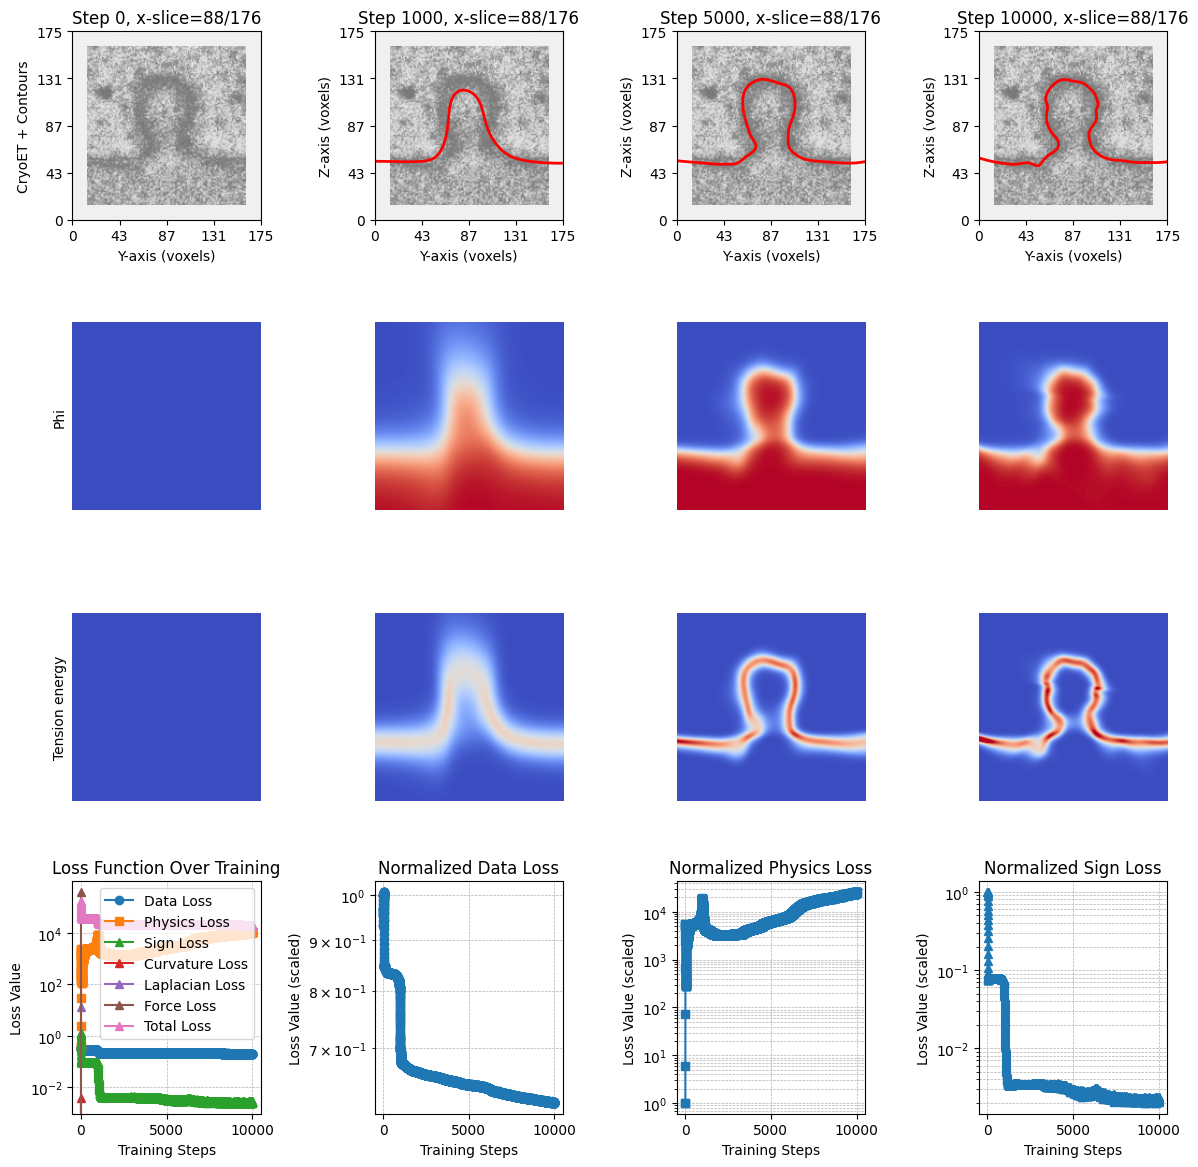

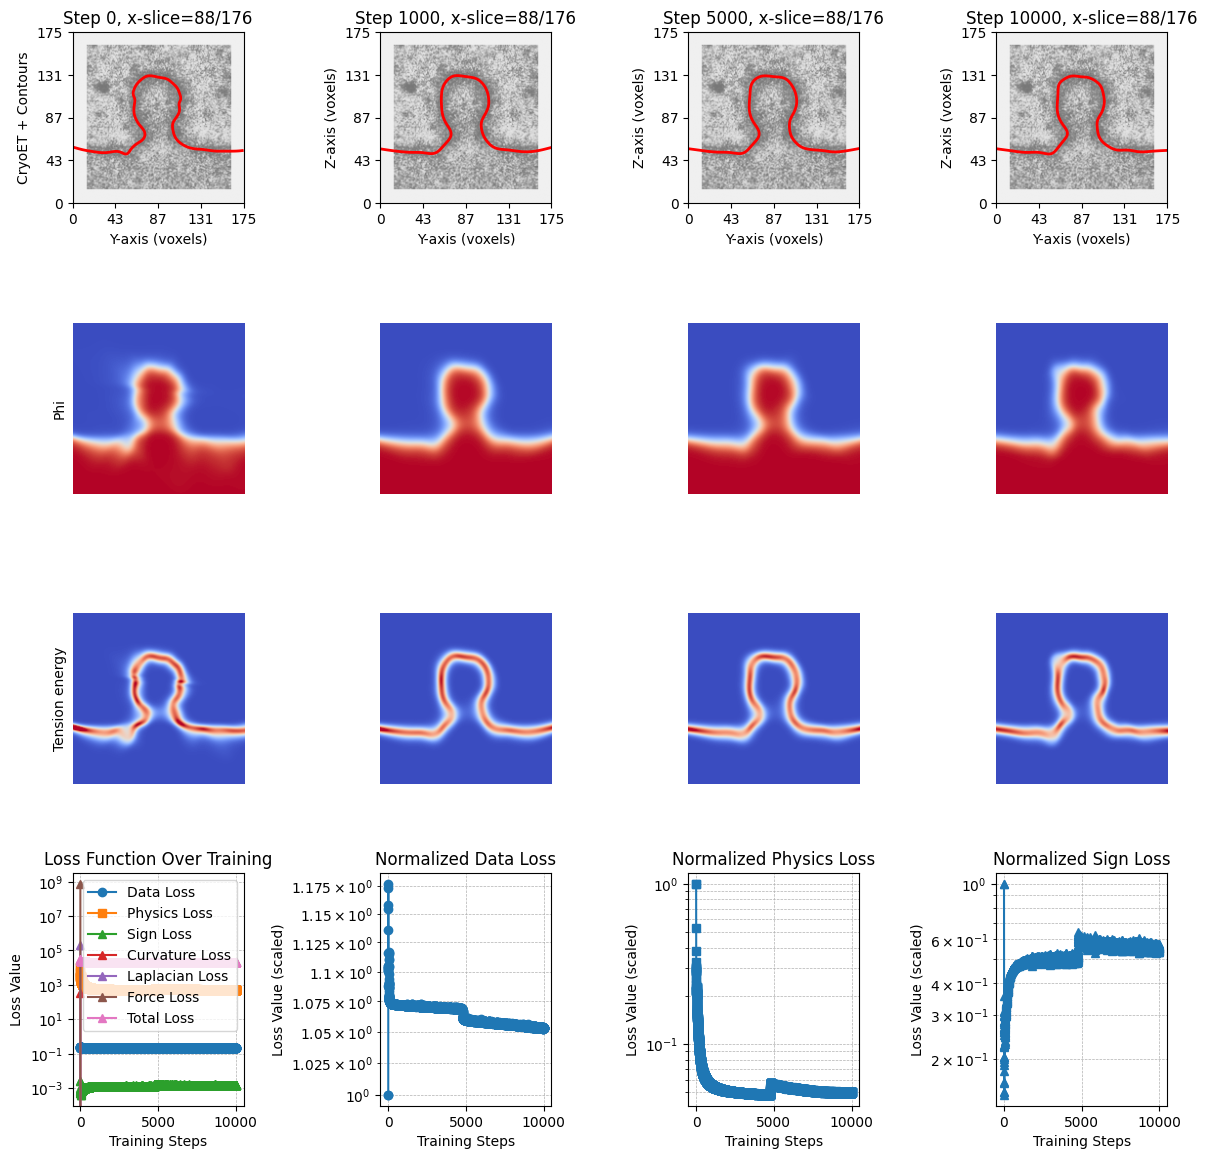

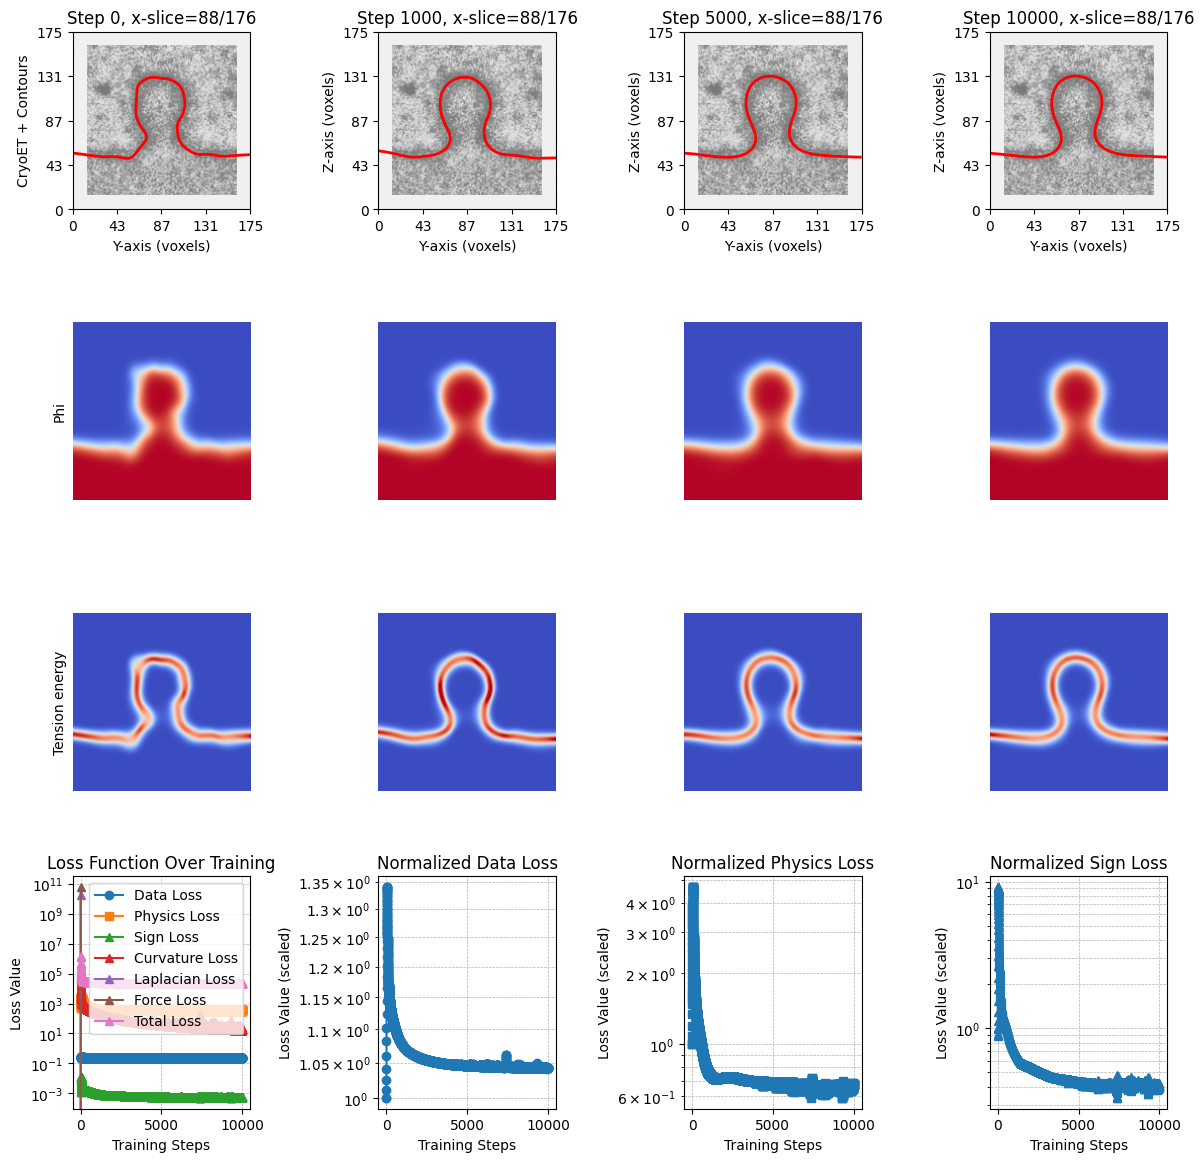

In [3]:
# =========================
#      MAIN SIMULATION
# =========================

data_id = "jrc_cos7-1b"
shape = "bud-11"
lambda_1 = 100000  # data loss
lambda_2 = 1       # phys loss
lambda_3 = 100000  # sign loss
lambda_4 = 10      # curv loss
lambda_5 = 0       # lapH loss (not used)
lambda_6 = 0       # forc loss (not used)


# Phase 0: lambda_2 = 0, lambda_4 = 0
run_one(
    data_id=data_id,
    shape=shape,
    sdf_pretrain="uniform",
    lambda_1=lambda_1,
    lambda_2=0,
    lambda_3=lambda_3,
    num_steps=10000,
    phase = 0,
)

# Phase 1: lambda_2 != 0, lambda_4 = 0
run_one(
    data_id=data_id,
    shape=shape,
    sdf_pretrain="checkpoint",
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    num_steps=10000,
    phase = 1,
)

sample_curv_points(
    data_id=data_id,
    shape=shape,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    num_curv = 5000,
)

# Phase 2: lambda_2 != 0, lambda_4 != 0
run_one(
    data_id=data_id,
    shape=shape,
    sdf_pretrain="checkpoint",
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    num_steps=10000,
    phase = 2,
)
